# 01. 30-Day Fed Funds Futures (ZQ) Data from Databento

The CME's **30-Day Fed Funds futures** (product code **ZQ**) are the raw
material behind the famous
[CME FedWatch tool](https://www.cmegroup.com/markets/interest-rates/cme-fedwatch-tool.html).
Each monthly contract settles at

$$ \text{settlement price} = 100 - \bar{r}, $$

where $\bar{r}$ is the **calendar-day average of the daily effective federal
funds rate (EFFR)** over the contract month, as published by the New York Fed.
Days without a published rate (weekends, holidays) carry forward the previous
day's rate.

That settlement rule is what makes ZQ prices interesting: buying the
September contract at 96.30 is a bet that fed funds will average
$100 - 96.30 = 3.70\%$ during September. The price *is* the market's
forecast of Fed policy for that month. In the next notebook we turn these
prices into FedWatch-style probabilities for the next FOMC decision; here we
get to know the data itself.

![CME 30-Day Fed Funds futures product page](assets/cme_zq_product_page.png)

*CME's [product page](https://www.cmegroup.com/markets/interest-rates/stirs/30-day-federal-fund.html)
for 30-Day Fed Funds futures — here quoting `ZQF7`, a symbol we will learn
to decode below.*

## How the data was pulled

This project follows the course convention: `pull_*` scripts hit the network
and cache to `_data/`; notebooks only ever `load_*` from that cache, so they
run offline. The pull lives in `pull_fed_funds_futures.py` and its core is
just this (shown here, **not** executed):

```python
import databento as db

client = db.Historical(key=DATABENTO_API_KEY)

query = dict(
    dataset="GLBX.MDP3",  # CME Globex market data
    symbols=["ZQ.FUT"],   # parent symbology: every listed ZQ contract at once
    stype_in="parent",
    schema="ohlcv-1d",    # one OHLCV bar per contract per trading day
    start=START_DATE,     # trailing ~6 months
    end=END_DATE,
)

cost = client.metadata.get_cost(**query)  # free metadata call
assert_query_is_free(cost)                # abort unless the estimate is $0.00

df = client.timeseries.get_range(**query).to_df()
```

Things worth noticing:

- **Dataset** `GLBX.MDP3` is CME Globex's market-by-order feed; Databento
  derives all simpler schemas from it. Our course subscription is
  historical-only (no live streaming), and history lags real time by about a
  day.
- **Parent symbology** (`ZQ.FUT`) asks for *all* listed ZQ contracts in one
  query — outright monthly contracts plus calendar spreads — instead of
  naming each contract.
- **Schema** `ohlcv-1d` gives daily open/high/low/close/volume bars, the
  coarsest (and cheapest) view of the data. The same query with
  `schema="trades"` would return every individual trade.
- **The free-data check.** Everything this project pulls is covered by the
  course's Databento subscription, so `metadata.get_cost` always comes back
  $0.00 for our query. `assert_query_is_free` verifies that *before*
  downloading anything and aborts otherwise, so no run of this pipeline can
  ever incur a charge — even if the query gets edited.

The cached file is a target of the `doit` pipeline. To refresh it with the
latest prices, run `doit forget pull && doit`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import fedwatch
import pull_fed_funds_futures

df = pull_fed_funds_futures.load_fed_funds_futures()
df.head()

,date,symbol,open,high,low,close,volume
0,2026-04-05,ZQK6-ZQQ6,-1.00,-1.00,-1.00,-1.00,31
1,2026-04-05,ZQK7-ZQN7,-4.00,-4.00,-4.00,-4.00,10
2,2026-04-05,ZQM6,96.36,96.36,96.36,96.36,28
3,2026-04-05,ZQJ6-ZQK6,0.50,0.50,0.50,0.50,22
4,2026-04-05,ZQQ6-ZQV6,1.00,1.50,1.00,1.50,362


## Reading the columns and the symbols

- `date` — the trading date of the bar (Databento stamps daily bars at
  00:00 UTC; the pull converts that to a plain date).
- `symbol` — the specific contract the bar belongs to.
- `open/high/low/close` — prices in index points (100 minus rate).
- `volume` — contracts traded that day.

A CME futures symbol has three parts: **root + month code + year digit**.
The month codes are a piece of exchange-floor history worth memorizing:

| Code | F | G | H | J | K | M | N | Q | U | V | X | Z |
|------|---|---|---|---|---|---|---|---|---|---|---|---|
| Month | Jan | Feb | Mar | Apr | May | Jun | Jul | Aug | Sep | Oct | Nov | Dec |

So `ZQU6` = ZQ + `U` (September) + `6` — the September 2026 contract. Note
the **single year digit is ambiguous**: `ZQU6` could just as well be 2016 or
2036. `fedwatch.parse_zq_contract_month` resolves it to the unique matching
year near the date of the data, which is safe because ZQ only lists about
three years of contracts at a time.

The parent-symbology pull also returns **calendar spreads** like
`ZQU6-ZQZ6` (buy September, sell December as a package). We don't need them,
so `fedwatch.filter_outright_contracts` keeps only symbols matching the
outright pattern.

In [2]:
df["symbol"].nunique(), sorted(df["symbol"].unique())[:12]

(188,
 ['ZQ:BF F7-G7-H7',
  'ZQ:BF F7-G7-J7',
  'ZQ:BF G7-H7-J7',
  'ZQ:BF G7-J7-K7',
  'ZQ:BF H7-J7-K7',
  'ZQ:BF J6-K6-M6',
  'ZQ:BF J7-K7-M7',
  'ZQ:BF J7-K7-N7',
  'ZQ:BF K6-M6-N6',
  'ZQ:BF K6-N6-Q6',
  'ZQ:BF K7-M7-N7',
  'ZQ:BF K7-N7-Q7'])

In [3]:
df_out = fedwatch.filter_outright_contracts(df).copy()
as_of = df_out["date"].max()
df_out["contract_month"] = pd.PeriodIndex(
    [fedwatch.parse_zq_contract_month(s, as_of) for s in df_out["symbol"]],
    freq="M",
)
df_out.head()

,date,symbol,open,high,low,close,volume,contract_month
2,2026-04-05,ZQM6,96.360,96.360,96.360,96.360,28,2026-06
5,2026-04-05,ZQH7,96.380,96.385,96.365,96.375,22,2027-03
11,2026-04-05,ZQK6,96.355,96.355,96.355,96.355,273,2026-05
12,2026-04-05,ZQZ6,96.345,96.360,96.345,96.355,12,2026-12
13,2026-04-05,ZQK7,96.365,96.380,96.365,96.380,47,2027-05


## Prices as implied rates

The settlement rule makes translation trivial: **implied average rate =
100 − price**. One practical wrinkle: contract months far in the future
trade thinly, so a contract may have *no bar at all* on a given day.
`fedwatch.latest_prices_by_contract` therefore takes each contract's **last
available close** on or before the as-of date rather than insisting on
today's bar.

In [4]:
latest = fedwatch.latest_prices_by_contract(df)
latest["implied_rate"] = fedwatch.implied_rate(latest["close"])
latest

,symbol,contract_month,date,close,implied_rate
0,ZQJ6,2026-04,2026-04-30,96.3600,3.6400
1,ZQK6,2026-05,2026-05-29,96.3725,3.6275
2,ZQM6,2026-06,2026-06-30,96.3750,3.6250
3,ZQN6,2026-07,2026-07-31,96.3725,3.6275
4,ZQQ6,2026-08,2026-08-31,96.3675,3.6325
5,ZQU6,2026-09,2026-09-30,96.2550,3.7450
6,ZQV6,2026-10,2026-10-01,96.1175,3.8825
7,ZQX6,2026-11,2026-10-01,96.0550,3.9450
8,ZQZ6,2026-12,2026-10-01,95.9200,4.0800
9,ZQF7,2027-01,2026-10-01,95.8550,4.1450


## Two pictures of the data

First, the price history of the nearest few contracts over our pull window.
Prices drift as the market updates its view of where the Fed is heading —
each line is a rolling referendum on one month's average fed funds rate.

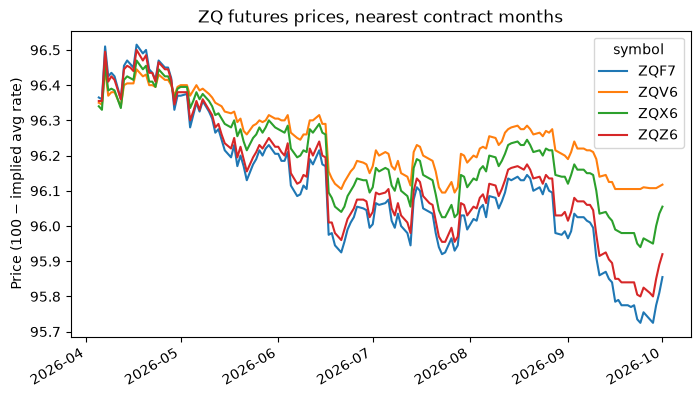

In [5]:
front_symbols = latest.loc[
    latest["contract_month"] >= pd.Period(as_of, freq="M"), "symbol"
].head(4)
prices = df_out[df_out["symbol"].isin(front_symbols)].pivot_table(
    index="date", columns="symbol", values="close"
)
ax = prices.plot(figsize=(8, 4.5))
ax.set_title("ZQ futures prices, nearest contract months")
ax.set_ylabel("Price (100 − implied avg rate)")
ax.set_xlabel("")
plt.show()

Second, the cross-section on the latest date: the implied average rate for
each upcoming contract month. This curve **is** the market's forecast of the
fed funds path — every step down (up) the market prices in is a future cut
(hike). FedWatch is essentially a careful reading of this curve around FOMC
meeting dates.

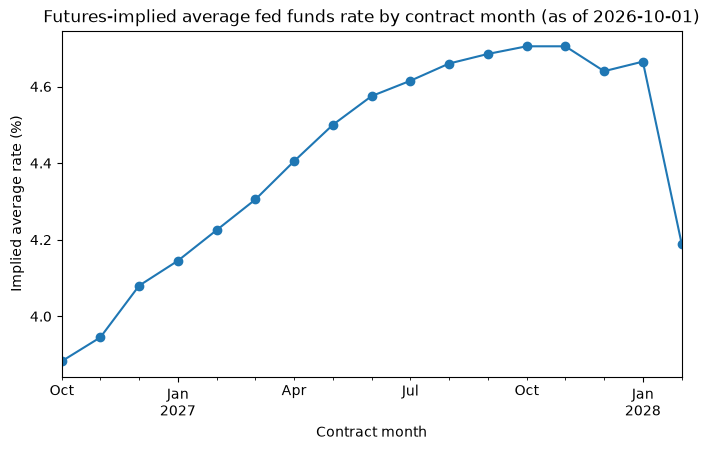

In [6]:
path = latest[latest["contract_month"] >= pd.Period(as_of, freq="M")].copy()
path["month"] = path["contract_month"].dt.to_timestamp()
ax = path.plot(x="month", y="implied_rate", marker="o", legend=False, figsize=(8, 4.5))
ax.set_title(f"Futures-implied average fed funds rate by contract month (as of {as_of.date()})")
ax.set_ylabel("Implied average rate (%)")
ax.set_xlabel("Contract month")
plt.show()

## Summary

- ZQ futures settle at 100 minus the monthly average EFFR, so prices map
  directly to market-expected policy rates.
- Databento's parent symbology + `ohlcv-1d` schema deliver every contract's
  daily bars in one query — free under the course subscription, and verified
  free ($0.00 estimate) before anything is downloaded.
- Symbols encode contract months (root + month code + year digit); spreads
  get filtered out, thin months use the last available close.

**Exercises**

1. Re-run `latest_prices_by_contract` with `as_of` set three months back.
   How did the implied rate path shift?
2. In a scratch script, use `client.metadata.get_record_count` (free, like
   `get_cost` — no data is downloaded) to compare our `ohlcv-1d` query with
   the same query at `ohlcv-1m` and `trades`. How fast does the volume of
   data grow as the schema gets finer?
3. Look up today's front-month contract volume. Why is it so much higher
   than the volume 18 months out?